PROYECTO FINAL CODERHOUSE: MORTALIDAD INFANTIL 2024

In [138]:
import importlib
import informe_sanitario

importlib.reload(informe_sanitario)

from informe_sanitario import InformeSanitario

informe = InformeSanitario("Mortalidad Infantil por Malformaciones Congénitas")

In [142]:
%%writefile informe_sanitario.py

from docx import Document
from docx.shared import Pt
from docx.enum.text import WD_PARAGRAPH_ALIGNMENT


class InformeSanitario:

    def __init__(self,
                 titulo,
                 *,  # Todos los argumentos que siguen deben ser de palabra clave
                 subtitulo="",
                 autor="",
                 institucion="",
                 fecha=""):

        self.doc = Document()

        self.titulo = titulo
        self.subtitulo = subtitulo
        self.autor = autor
        self.institucion = institucion
        self.fecha = fecha

        self.numero_figura = 1
        self.numero_tabla = 1

        self._crear_portada()


    def _crear_portada(self):

        titulo = self.doc.add_heading(self.titulo, level=0)
        titulo.alignment = WD_PARAGRAPH_ALIGNMENT.CENTER

        if self.subtitulo:
            p = self.doc.add_paragraph()
            p.alignment = WD_PARAGRAPH_ALIGNMENT.CENTER
            p.add_run(self.subtitulo).bold = True

        self.doc.add_paragraph()

        p = self.doc.add_paragraph()

        p.alignment = WD_PARAGRAPH_ALIGNMENT.CENTER

        p.add_run(f"Autor: {self.autor}\n")
        p.add_run(f"{self.institucion}\n")
        p.add_run(f"{self.fecha}")

        self.doc.add_page_break()


    def seccion(self, titulo):

        self.doc.add_heading(titulo, level=1)


    def subseccion(self, titulo):

        self.doc.add_heading(titulo, level=2)


    def texto(self, texto):

        p = self.doc.add_paragraph()

        run = p.add_run(texto)

        run.font.size = Pt(11)


    def tabla(self, df, titulo=""): # Nuevo método para añadir tablas
        if titulo:
            self.doc.add_heading(f'Tabla {self.numero_tabla}: {titulo}', level=3)

        table = self.doc.add_table(rows=1, cols=len(df.columns))
        table.style = 'Table Grid'

        # Añadir encabezados de columna
        hdr_cells = table.rows[0].cells
        for i, col_name in enumerate(df.columns):
            hdr_cells[i].text = col_name

        # Añadir filas de datos
        for index, row in df.iterrows():
            row_cells = table.add_row().cells
            for i, item in enumerate(row):
                row_cells[i].text = str(item)

        self.doc.add_paragraph() # Añadir un espacio después de la tabla
        self.numero_tabla += 1


    def guardar(self, ruta):

        self.doc.save(ruta)

        print(f"Informe guardado en:\n{ruta}")

Overwriting informe_sanitario.py


In [102]:
import importlib
import informe_sanitario
importlib.reload(informe_sanitario)
from informe_sanitario import InformeSanitario

informe = InformeSanitario(
    "Mortalidad Infantil por Malformaciones Congénitas",
    subtitulo="Análisis Exploratorio de Datos",
    autor="Nicolás Martín",
    institucion="Coderhouse",
    fecha="Julio 2026"
)

In [103]:
informe.seccion("Introducción")

In [104]:
informe.texto("""
Este informe analiza la mortalidad infantil por
malformaciones congénitas en Argentina durante
el año 2024.
""")

In [146]:
import importlib
import informe_sanitario
importlib.reload(informe_sanitario)

informe = informe_sanitario.InformeSanitario(
    titulo="Prueba de tablas",
    autor="Nicolás Martín"
)

In [140]:
import pandas as pd

df_prueba = pd.DataFrame({
    "Provincia": ["Buenos Aires", "Córdoba", "Santa Fe"],
    "Casos": [120, 85, 67],
    "Tasa": [3.4, 2.8, 2.5]
})

In [147]:
informe.seccion("Resultados")

informe.tabla(
    df_prueba,
    titulo="Casos por provincia"
)

In [135]:
informe.guardar(
    "/content/drive/MyDrive/coderhouse/primer_informe.docx"
)

Informe guardado en:
/content/drive/MyDrive/coderhouse/primer_informe.docx


En este trabajo analizamos datos extraídos del sitio web de la Dirección de Estadísticas e Información de Salud (DEIS) del Estado argentino. El objetivo es analizar la mortalidad infantil por malformaciones congénitas en Argentina durante el año 2024, con foco en la distribución territorial y etaria de los casos.

**VARIABLES**
- VD: tipo de malformación congénita (cardiopatías congénitas vs otras malformaciones)
- VI: provincia de residencia, subgrupo etario

## OBJETIVO

El presente trabajo tiene dos objetivos complementarios. Por un lado, desarrollar un modelo de clasificación que permita predecir si una defunción infantil por malformación congénita corresponde a una cardiopatía congénita (Q20-Q28) o a otra malformación congénita, en función del subgrupo etario y la provincia de residencia. Por otro lado, analizar la tasa de mortalidad infantil por provincia y región geográfica, con el fin de identificar desigualdades territoriales en el acceso a la salud materno-infantil en Argentina durante el año 2024.

## CONTEXTO COMERCIAL

El Ministerio de Salud de la Nación ha identificado un aumento en la tasa de mortalidad infantil en el último relevamiento demográfico correspondiente al año 2024 (aumento registrado de 0,5 puntos más respecto de 2023). Ante este escenario, surge la necesidad de analizar en profundidad las causas de muerte en menores de un año, con foco en las malformaciones congénitas, que representan la segunda causa de mortalidad infantil en Argentina. El análisis busca brindar información que oriente la toma de decisiones en materia de políticas públicas de salud, priorizando la detección prenatal de cardiopatías congénitas y la reducción de las brechas regionales existentes.

## HIPÓTESIS

Un modelo de aprendizaje automático podrá clasificar con precisión las defunciones infantiles por malformación congénita en cardiopatías congénitas o en otras malformaciones, a partir del subgrupo etario y la provincia de residencia, esperando alcanzar un F1-score superior a 0.70. Asimismo, se espera evidenciar patrones de desigualdad territorial, con tasas de mortalidad infantil por malformaciones congénitas significativamente más elevadas en las regiones NOA y NEA respecto de las regiones Pampeana y Patagónica.

## EDA — ANÁLISIS EXPLORATORIO DE DATOS

In [106]:
# IMPORTS
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

In [107]:
ruta = '/content/drive/MyDrive/coderhouse/'
tabla = f'{ruta}datos_sobre_defunciones_2024.csv'

In [108]:
# CARGA DEL DATASET ORIGINAL SIN MODIFICACIONES
df_raw = pd.read_csv(tabla, encoding='latin1', sep=';')

print('=== DATASET ORIGINAL ===')
print(f'Filas:    {df_raw.shape[0]:,}')
print(f'Columnas: {df_raw.shape[1]}')
print(f'Nombres:  {list(df_raw.columns)}')
print()
print(df_raw.head(5).to_string())

=== DATASET ORIGINAL ===
Filas:    54,251
Columnas: 6
Nombres:  ['ï»¿PROVRES', 'SEXO', 'CAUSA', 'MAT', 'GRUPEDAD', 'CUENTA']

   ï»¿PROVRES  SEXO CAUSA  MAT                GRUPEDAD  CUENTA
0           2     1   A16  NaN              10.15 a 19       2
1           2     1   A16  NaN              12.25 a 29       1
2           2     1   A16  NaN              20.65 a 69       3
3           2     1   A16  NaN            24.85 y mÃ¡s       2
4           2     1   A41  NaN  03.28 dÃ­as a 11 meses       1


In [109]:
# EXPLORACIÓN INICIAL
print('=== DIMENSIONES ===')
print(f'Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}')
print()
print('=== TIPOS DE DATOS ===')
print(df_raw.dtypes)
print()
print('=== VALORES NULOS ===')
nulos = df_raw.isnull().sum()
pct   = (nulos / len(df_raw) * 100).round(2)
print(pd.DataFrame({'Nulos': nulos, 'Porcentaje': pct.astype(str) + '%'}))
print()
print('=== PRIMERAS FILAS ===')
print(df_raw.head(5).to_string())

=== DIMENSIONES ===
Filas: 54,251 | Columnas: 6

=== TIPOS DE DATOS ===
ï»¿PROVRES     int64
SEXO           int64
CAUSA         object
MAT           object
GRUPEDAD      object
CUENTA         int64
dtype: object

=== VALORES NULOS ===
            Nulos Porcentaje
ï»¿PROVRES      0       0.0%
SEXO            0       0.0%
CAUSA           0       0.0%
MAT         54056     99.64%
GRUPEDAD        0       0.0%
CUENTA          0       0.0%

=== PRIMERAS FILAS ===
   ï»¿PROVRES  SEXO CAUSA  MAT                GRUPEDAD  CUENTA
0           2     1   A16  NaN              10.15 a 19       2
1           2     1   A16  NaN              12.25 a 29       1
2           2     1   A16  NaN              20.65 a 69       3
3           2     1   A16  NaN            24.85 y mÃ¡s       2
4           2     1   A41  NaN  03.28 dÃ­as a 11 meses       1


/tmp/ipykernel_664/799134586.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 640x480 with 0 Axes>

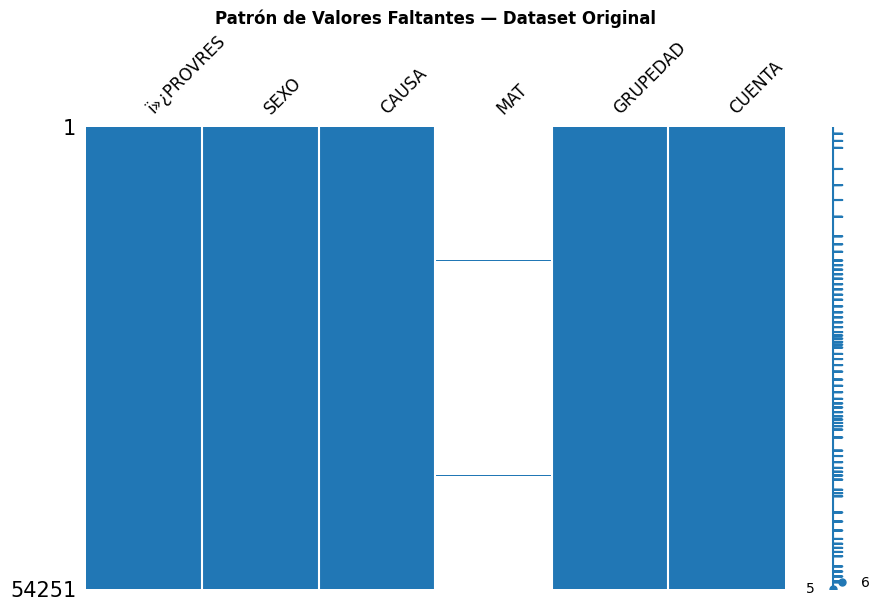

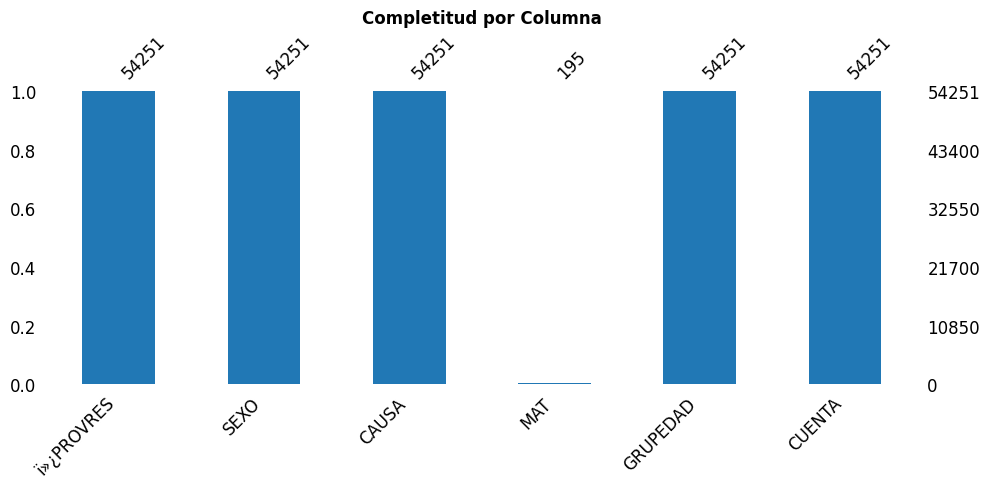

=== RESUMEN DE VALORES FALTANTES ===
            Nulos Porcentaje
ï»¿PROVRES      0       0.0%
SEXO            0       0.0%
CAUSA           0       0.0%
MAT         54056     99.64%
GRUPEDAD        0       0.0%
CUENTA          0       0.0%


In [110]:
# ANÁLISIS DE VALORES FALTANTES CON MISSINGNO
!pip install missingno -q

import missingno as msno

# Matrix — patrón de nulos por fila
plt.figure()
msno.matrix(df_raw, figsize=(10, 6), fontsize=12, color=(0.13, 0.47, 0.71))
plt.title('Patrón de Valores Faltantes — Dataset Original', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ruta}missing_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar — completitud por columna
plt.figure()
msno.bar(df_raw, figsize=(10, 5), fontsize=12, color=(0.13, 0.47, 0.71))
plt.title('Completitud por Columna', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ruta}missing_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen numérico
print('=== RESUMEN DE VALORES FALTANTES ===')
nulos = df_raw.isnull().sum()
pct   = (nulos / len(df_raw) * 100).round(2)
print(pd.DataFrame({'Nulos': nulos, 'Porcentaje': pct.astype(str) + '%'}))

### Análisis de Valores Faltantes

El análisis de missingness revela un patrón claro y concentrado en una única variable:

**MAT (Muerte Materna):** presenta el 99.6% de valores nulos. Este comportamiento no es aleatorio sino estructural — la variable registra si una defunción corresponde a una muerte materna, pero al filtrar mortalidad infantil por malformaciones congénitas, ningún caso puede ser clasificado como muerte materna.

**Resto de variables:** `PROVRES`, `SEXO`, `CAUSA`, `GRUPEDAD` y `CUENTA` presentan completitud del 100%.

**Decisión:** la columna `MAT` se descarta del análisis. El resto de variables se incorporan al pipeline sin necesidad de imputación sobre datos reales.

## PREPROCESAMIENTO

In [111]:
# VARIABLES AUXILIARES
mapa_provincias = {
    2: 'CABA', 6: 'Bs.As', 42: 'La Pampa', 14: 'Córdoba', 82: 'Santa Fe',
    10: 'Catamarca', 90: 'Tucumán', 86: 'Santiago del Estero', 38: 'Jujuy',
    66: 'Salta', 22: 'Chaco', 34: 'Formosa', 30: 'Entre Ríos', 18: 'Corrientes',
    54: 'Misiones', 26: 'Chubut', 58: 'Neuquén', 62: 'Río Negro',
    78: 'Santa Cruz', 94: 'Tierra del Fuego', 70: 'San Juan',
    74: 'San Luis', 50: 'Mendoza', 46: 'La Rioja'
}

mapa_regiones = {
    'Jujuy': 'NOA', 'Salta': 'NOA', 'Tucumán': 'NOA',
    'Catamarca': 'NOA', 'Santiago del Estero': 'NOA',
    'Formosa': 'NEA', 'Chaco': 'NEA',
    'Corrientes': 'NEA', 'Misiones': 'NEA',
    'Mendoza': 'Cuyo', 'San Juan': 'Cuyo',
    'San Luis': 'Cuyo', 'La Rioja': 'Cuyo',
    'Córdoba': 'Pampeana', 'Santa Fe': 'Pampeana',
    'Entre Ríos': 'Pampeana', 'La Pampa': 'Pampeana',
    'Bs.As': 'Pampeana', 'CABA': 'Pampeana',
    'Neuquén': 'Patagónica', 'Río Negro': 'Patagónica',
    'Chubut': 'Patagónica', 'Santa Cruz': 'Patagónica',
    'Tierra del Fuego': 'Patagónica'
}

grupos_infantiles = [
    '01.0 a 6 días',
    '02.7 a 27 días',
    '03.28 días a 11 meses',
    '04.1 año',
    '031. Menor de 1 año  Sin especificar'
]

mapa_subgrupo = {
    '01.0 a 6 días':                        'neonatal_precoz',
    '02.7 a 27 días':                       'neonatal_tardio',
    '03.28 días a 11 meses':                'postneonatal',
    '04.1 año':                             'postneonatal',
    '031. Menor de 1 año  Sin especificar': 'postneonatal'
}

codigos_cardiopatias = [f'Q{i}' for i in range(20, 29)]

codigos_otras = (
    ['Q00', 'Q01', 'Q02', 'Q03', 'Q04', 'Q05', 'Q06', 'Q07'] +
    [f'Q{i}' for i in range(31, 46)] +
    [f'Q{i}' for i in range(60, 66)] +
    ['Q74', 'Q75', 'Q76', 'Q77', 'Q78', 'Q79', 'Q82', 'Q85', 'Q87', 'Q89'] +
    ['Q90', 'Q91', 'Q92', 'Q93', 'Q97', 'Q98', 'Q99']
)

todos_los_codigos_Q = codigos_cardiopatias + codigos_otras

print('✓ Variables auxiliares definidas')

✓ Variables auxiliares definidas


In [112]:
# FUNCIÓN procesar_csv
def procesar_csv(file_path):
    # 1. Detectar separador
    with open(file_path, 'r', encoding='latin1') as f:
        primera_linea = f.readline()
    sep = ';' if primera_linea.count(';') > primera_linea.count(',') else ','

    # 2. Leer archivo
    try:
        df = pd.read_csv(file_path, sep=sep, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, sep=sep, encoding='latin1')

    # 3. Eliminar MAT (99% nulos)
    if 'MAT' in df.columns:
        df = df.drop(columns=['MAT'])

    # 4. Filtrar mortalidad infantil
    df = df[df['GRUPEDAD'].isin(grupos_infantiles)].copy()

    # 5. Filtrar causas Q (malformaciones congénitas)
    df = df[df['CAUSA'].isin(todos_los_codigos_Q)].copy()

    # 6. Filtrar SEXO válido
    df = df[df['SEXO'].isin([1, 2])].copy()

    # 7. Filtrar provincias y mapear nombres
    df = df[df['PROVRES'].isin(mapa_provincias.keys())].copy()
    df['PROVINCIA'] = df['PROVRES'].map(mapa_provincias)
    df = df.drop(columns=['PROVRES'])

    # 8. Agregar región
    df['REGION'] = df['PROVINCIA'].map(mapa_regiones)

    # 9. Subgrupo etario
    df['PER_DEF'] = df['GRUPEDAD'].map(mapa_subgrupo)

    # 10. TARGET binario
    df['ENFERMEDAD'] = df['CAUSA'].apply(
        lambda x: 'cardiopatias' if x in codigos_cardiopatias else 'otras_malformaciones'
    )

    # 11. Renombrar columnas
    df = df.rename(columns={
        'SEXO':    'GENERO',
        'CUENTA':  'CANTIDAD',
        'GRUPEDAD': 'EDAD_DEF'
    })

    # 12. Eliminar GENERO
    df = df.drop(columns=['GENERO'])

    # 13. Limpiar prefijo numérico de EDAD_DEF
    df['EDAD_DEF'] = df['EDAD_DEF'].str.replace(r'^\d+\.\s*', '', regex=True)

    return df

In [113]:
# EJECUTAR procesar_csv
df = procesar_csv(tabla)

print(f'Filas:    {len(df)}')
print(f'Columnas: {list(df.columns)}')
print()
print('ENFERMEDAD:')
print(df['ENFERMEDAD'].value_counts())
print()
print('PROVINCIA:')
print(df['PROVINCIA'].value_counts())
print()
df.head(10)

Filas:    611
Columnas: ['CAUSA', 'EDAD_DEF', 'CANTIDAD', 'PROVINCIA', 'REGION', 'PER_DEF', 'ENFERMEDAD']

ENFERMEDAD:
ENFERMEDAD
otras_malformaciones    393
cardiopatias            218
Name: count, dtype: int64

PROVINCIA:
PROVINCIA
Bs.As                  123
Santa Fe                48
Córdoba                 47
Mendoza                 38
Chaco                   37
Corrientes              36
Misiones                32
CABA                    29
Tucumán                 29
Salta                   23
San Juan                22
Entre Ríos              21
Santiago del Estero     20
Formosa                 18
Neuquén                 16
Catamarca               12
Río Negro               12
La Rioja                11
San Luis                11
Jujuy                    9
Chubut                   8
Santa Cruz               5
La Pampa                 2
Tierra del Fuego         2
Name: count, dtype: int64



,CAUSA,EDAD_DEF,CANTIDAD,PROVINCIA,REGION,PER_DEF,ENFERMEDAD
386,Q24,0 a 6 días,1,CABA,Pampeana,neonatal_precoz,cardiopatias
387,Q25,7 a 27 días,1,CABA,Pampeana,neonatal_tardio,cardiopatias
388,Q33,0 a 6 días,1,CABA,Pampeana,neonatal_precoz,otras_malformaciones
390,Q90,28 días a 11 meses,1,CABA,Pampeana,postneonatal,otras_malformaciones
391,Q98,28 días a 11 meses,1,CABA,Pampeana,postneonatal,otras_malformaciones
802,Q90,7 a 27 días,1,CABA,Pampeana,neonatal_tardio,otras_malformaciones
804,Q91,28 días a 11 meses,1,CABA,Pampeana,postneonatal,otras_malformaciones
1234,Q20,28 días a 11 meses,2,CABA,Pampeana,postneonatal,cardiopatias
1236,Q60,0 a 6 días,1,CABA,Pampeana,neonatal_precoz,otras_malformaciones
1237,Q87,28 días a 11 meses,1,CABA,Pampeana,postneonatal,otras_malformaciones


### Paso previo a la visualización

Para calcular la tasa de mortalidad infantil necesitamos el dato de nacidos vivos por provincia. El siguiente paso es incorporar ese archivo para poder calcular la tasa como:

**Tasa = (defunciones / nacidos vivos) x 1000**

In [114]:
# PROCESAR NACIDOS VIVOS
nacidos = pd.read_csv(f'{ruta}datos_sobre_nacidos_vivos_2024.csv',
                       encoding='latin1', sep=';')
nacidos.columns = nacidos.columns.str.replace('ï»¿', '')
nacidos['PROVINCIA'] = nacidos['PROVRES'].map(mapa_provincias)
nacidos_prov = nacidos.groupby('PROVINCIA')['CUENTA'].sum().reset_index()
nacidos_prov.columns = ['PROVINCIA', 'NACIDOS_VIVOS']

print('Nacidos vivos por provincia:')
print(nacidos_prov.sort_values('NACIDOS_VIVOS', ascending=False).to_string(index=False))

Nacidos vivos por provincia:
          PROVINCIA  NACIDOS_VIVOS
              Bs.As         147081
            Córdoba          33873
           Santa Fe          33713
               CABA          21454
            Mendoza          18505
            Tucumán          16661
           Misiones          16469
              Salta          14410
              Chaco          14350
         Entre Ríos          12548
         Corrientes          12538
Santiago del Estero          11401
           San Juan           8701
            Neuquén           6790
          Río Negro           6721
            Formosa           6711
              Jujuy           6352
             Chubut           5054
           San Luis           4410
          Catamarca           3866
           La Rioja           3503
           La Pampa           3039
         Santa Cruz           2696
   Tierra del Fuego           1259


In [115]:
# CALCULAR TASA DE MORTALIDAD POR PROVINCIA
defunciones_prov = df.groupby('PROVINCIA')['CANTIDAD'].sum().reset_index()
defunciones_prov.columns = ['PROVINCIA', 'DEFUNCIONES']

tasa_prov = defunciones_prov.merge(nacidos_prov, on='PROVINCIA', how='left')
tasa_prov['TASA_MORTALIDAD'] = (tasa_prov['DEFUNCIONES'] / tasa_prov['NACIDOS_VIVOS'] * 1000).round(2)
tasa_prov['REGION'] = tasa_prov['PROVINCIA'].map(mapa_regiones)

print(tasa_prov.sort_values('TASA_MORTALIDAD', ascending=False).to_string(index=False))

          PROVINCIA  DEFUNCIONES  NACIDOS_VIVOS  TASA_MORTALIDAD     REGION
              Chaco           56          14350             3.90        NEA
           La Rioja           13           3503             3.71       Cuyo
         Corrientes           45          12538             3.59        NEA
           Misiones           54          16469             3.28        NEA
           San Juan           28           8701             3.22       Cuyo
          Catamarca           12           3866             3.10        NOA
            Neuquén           19           6790             2.80 Patagónica
           San Luis           12           4410             2.72       Cuyo
            Formosa           18           6711             2.68        NEA
            Mendoza           47          18505             2.54       Cuyo
            Tucumán           41          16661             2.46        NOA
              Bs.As          358         147081             2.43   Pampeana
            

In [116]:
# TASA POR REGIÓN
tasa_region = tasa_prov.groupby('REGION')[['DEFUNCIONES', 'NACIDOS_VIVOS']].sum().reset_index()
tasa_region['TASA_MORTALIDAD'] = (tasa_region['DEFUNCIONES'] / tasa_region['NACIDOS_VIVOS'] * 1000).round(2)
tasa_region = tasa_region.sort_values('TASA_MORTALIDAD', ascending=False)

print(tasa_region.to_string(index=False))

    REGION  DEFUNCIONES  NACIDOS_VIVOS  TASA_MORTALIDAD
       NEA          173          50068             3.46
      Cuyo          100          35119             2.85
       NOA          126          52690             2.39
  Pampeana          567         251708             2.25
Patagónica           47          22520             2.09


In [117]:
# NÚMEROS ABSOLUTOS POR PROVINCIA Y REGIÓN
print('=== NÚMEROS ABSOLUTOS ===')
print()

# Total nacional
total_nacional = df.groupby('ENFERMEDAD')['CANTIDAD'].sum()
print('TOTAL NACIONAL:')
print(total_nacional)
print(f'Total general: {total_nacional.sum()}')
print()

# Por provincia
print('POR PROVINCIA:')
abs_prov = df.groupby(['PROVINCIA', 'ENFERMEDAD'])['CANTIDAD'].sum().unstack(fill_value=0)
abs_prov['TOTAL'] = abs_prov.sum(axis=1)
abs_prov = abs_prov.sort_values('TOTAL', ascending=False)
print(abs_prov.to_string())
print()

# Por región
print('POR REGIÓN:')
abs_region = df.groupby(['REGION', 'ENFERMEDAD'])['CANTIDAD'].sum().unstack(fill_value=0)
abs_region['TOTAL'] = abs_region.sum(axis=1)
abs_region = abs_region.sort_values('TOTAL', ascending=False)
print(abs_region.to_string())
print()

# Por subgrupo etario
print('POR SUBGRUPO ETARIO:')
abs_etario = df.groupby(['PER_DEF', 'ENFERMEDAD'])['CANTIDAD'].sum().unstack(fill_value=0)
abs_etario['TOTAL'] = abs_etario.sum(axis=1)
print(abs_etario.to_string())

=== NÚMEROS ABSOLUTOS ===

TOTAL NACIONAL:
ENFERMEDAD
cardiopatias            479
otras_malformaciones    534
Name: CANTIDAD, dtype: int64
Total general: 1013

POR PROVINCIA:
ENFERMEDAD           cardiopatias  otras_malformaciones  TOTAL
PROVINCIA                                                     
Bs.As                         193                   165    358
Córdoba                        38                    39     77
Santa Fe                       32                    40     72
Chaco                          25                    31     56
Misiones                       32                    22     54
Mendoza                        14                    33     47
Corrientes                     19                    26     45
Tucumán                        14                    27     41
CABA                           13                    21     34
Salta                          21                    12     33
San Juan                       15                    13     28
Santia

=== TRANSFORMACIÓN: ABSOLUTOS → TASAS (x1000 nacidos vivos) ===

Fórmula: TASA = (defunciones / nacidos_vivos) x 1000

TASA POR PROVINCIA:
          PROVINCIA  TOTAL  NACIDOS_VIVOS  TASA_CARDIOPATIAS  TASA_OTRAS  TASA_TOTAL
              Chaco     56          14350             1.7422      2.1603      3.9024
           La Rioja     13           3503             0.8564      2.8547      3.7111
         Corrientes     45          12538             1.5154      2.0737      3.5891
           Misiones     54          16469             1.9430      1.3358      3.2789
           San Juan     28           8701             1.7239      1.4941      3.2180
          Catamarca     12           3866             1.2933      1.8107      3.1040
            Neuquén     19           6790             1.1782      1.6200      2.7982
           San Luis     12           4410             0.6803      2.0408      2.7211
            Formosa     18           6711             0.8941      1.7881      2.6822
           

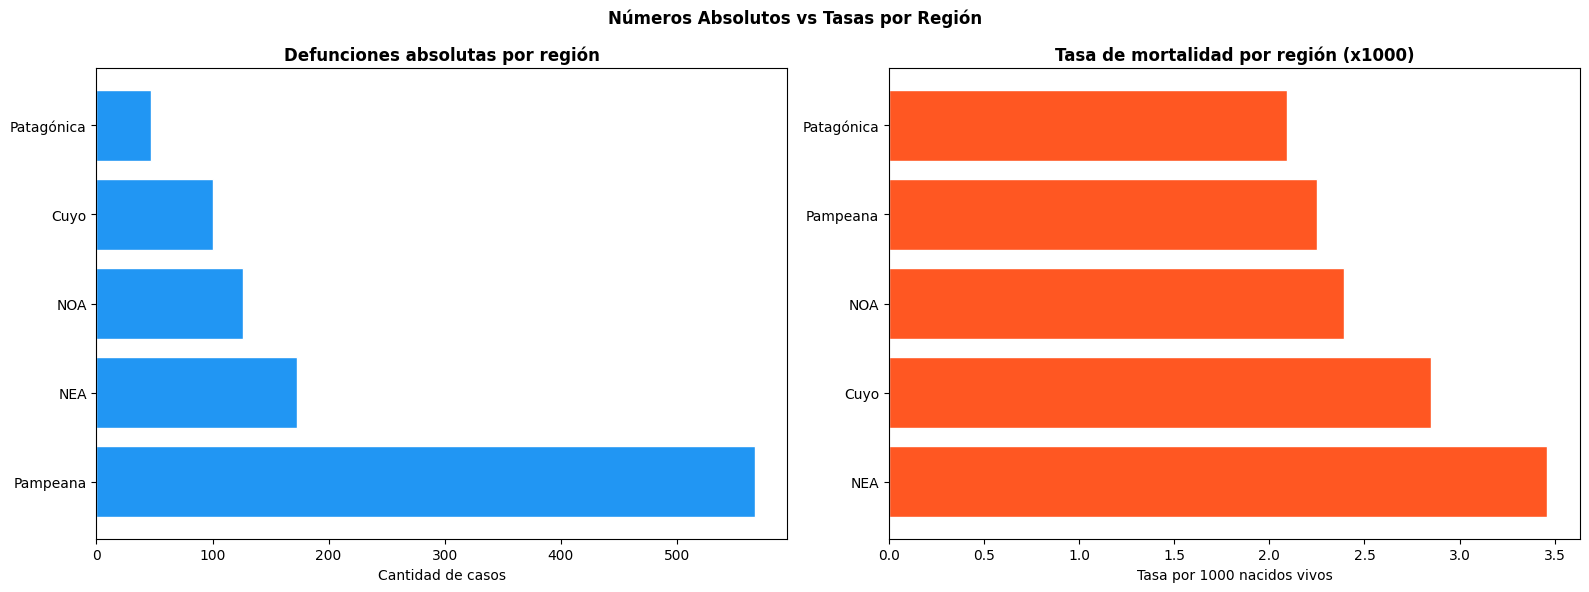

In [118]:
# TRANSFORMACIÓN ABSOLUTOS → TASAS
print('=== TRANSFORMACIÓN: ABSOLUTOS → TASAS (x1000 nacidos vivos) ===')
print()
print('Fórmula: TASA = (defunciones / nacidos_vivos) x 1000')
print()

# Tasa completa por provincia
tasa_completa = abs_prov.reset_index().merge(nacidos_prov, on='PROVINCIA', how='left')
tasa_completa['TASA_TOTAL']        = (tasa_completa['TOTAL'] / tasa_completa['NACIDOS_VIVOS'] * 1000).round(4)
tasa_completa['TASA_CARDIOPATIAS'] = (tasa_completa['cardiopatias'] / tasa_completa['NACIDOS_VIVOS'] * 1000).round(4)
tasa_completa['TASA_OTRAS']        = (tasa_completa['otras_malformaciones'] / tasa_completa['NACIDOS_VIVOS'] * 1000).round(4)
tasa_completa = tasa_completa.sort_values('TASA_TOTAL', ascending=False)

print('TASA POR PROVINCIA:')
print(tasa_completa[['PROVINCIA', 'TOTAL', 'NACIDOS_VIVOS',
                      'TASA_CARDIOPATIAS', 'TASA_OTRAS',
                      'TASA_TOTAL']].to_string(index=False))
print()

# Visualización absolutos vs tasas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Números Absolutos vs Tasas por Región', fontweight='bold')

axes[0].barh(abs_region.index, abs_region['TOTAL'], color='#2196F3', edgecolor='white')
axes[0].set_title('Defunciones absolutas por región', fontweight='bold')
axes[0].set_xlabel('Cantidad de casos')

axes[1].barh(tasa_region['REGION'], tasa_region['TASA_MORTALIDAD'],
             color='#FF5722', edgecolor='white')
axes[1].set_title('Tasa de mortalidad por región (x1000)', fontweight='bold')
axes[1].set_xlabel('Tasa por 1000 nacidos vivos')

plt.tight_layout()
plt.savefig(f'{ruta}absolutos_vs_tasas.png', dpi=150, bbox_inches='tight')
plt.show()

In [119]:
# ESTADÍSTICAS DESCRIPTIVAS — TASA DE MORTALIDAD
tasa = tasa_prov['TASA_MORTALIDAD']

media    = round(tasa.mean(), 4)
mediana  = round(tasa.median(), 4)
moda     = round(tasa.mode()[0], 4)
varianza = round(tasa.var(), 4)
desvio   = round(tasa.std(), 4)
q1       = round(tasa.quantile(0.25), 4)
q3       = round(tasa.quantile(0.75), 4)
p10      = round(tasa.quantile(0.10), 4)
p90      = round(tasa.quantile(0.90), 4)
iqr      = round((q3 - q1), 4)

prov_max = tasa_prov.loc[tasa_prov['TASA_MORTALIDAD'].idxmax()]
prov_min = tasa_prov.loc[tasa_prov['TASA_MORTALIDAD'].idxmin()]

print('=== MEDIDAS ESTADÍSTICAS — TASA DE MORTALIDAD (x1000 nacidos vivos) ===')
print(f'Media:               {media}')
print(f'Mediana:             {mediana}')
print(f'Moda:                {moda}')
print(f'Varianza:            {varianza}')
print(f'Desviación estándar: {desvio}')
print(f'Q1 (25%):            {q1}')
print(f'Q3 (75%):            {q3}')
print(f'IQR (Q3-Q1):         {iqr}')
print(f'Percentil 10:        {p10}')
print(f'Percentil 90:        {p90}')
print()
print(f'Provincia con mayor tasa: {prov_max["PROVINCIA"]} ({prov_max["TASA_MORTALIDAD"]})')
print(f'Provincia con menor tasa: {prov_min["PROVINCIA"]} ({prov_min["TASA_MORTALIDAD"]})')

=== MEDIDAS ESTADÍSTICAS — TASA DE MORTALIDAD (x1000 nacidos vivos) ===
Media:               2.4462
Mediana:             2.36
Moda:                1.58
Varianza:            0.5902
Desviación estándar: 0.7683
Q1 (25%):            1.925
Q3 (75%):            2.875
IQR (Q3-Q1):         0.95
Percentil 10:        1.583
Percentil 90:        3.497

Provincia con mayor tasa: Chaco (3.9)
Provincia con menor tasa: La Pampa (0.66)


### Interpretación de Estadísticas

1. **Distribución central:** la diferencia entre media y mediana indica la presencia de provincias con tasas extremas que elevan el promedio.

2. **Variabilidad:** la desviación estándar refleja una dispersión considerable entre provincias, evidenciando desigualdades territoriales.

3. **Desigualdad territorial:** la brecha entre la provincia con mayor y menor tasa evidencia inequidades estructurales en el acceso a la salud materno-infantil.

4. **Contexto de negocio:** las provincias por encima del percentil 90 representan las jurisdicciones prioritarias para intervención del Ministerio de Salud.

## VISUALIZACIONES

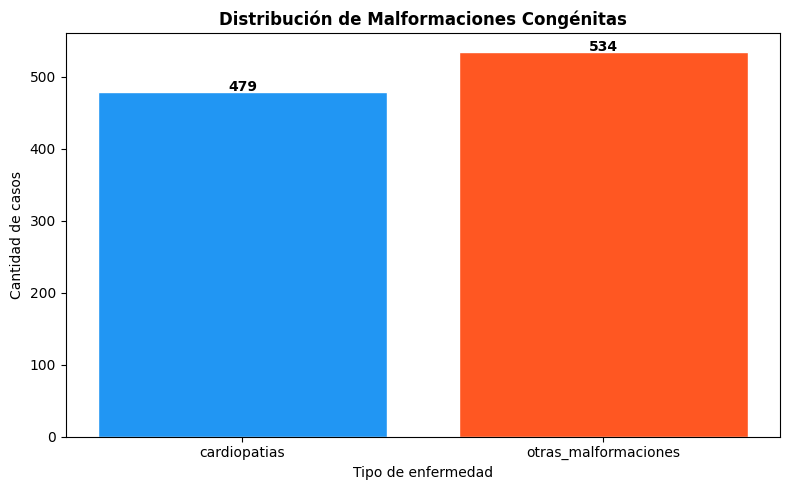

In [120]:
# GRÁFICO 1 — Distribución de enfermedades
conteo_target = df.groupby('ENFERMEDAD')['CANTIDAD'].sum()

plt.figure(figsize=(8, 5))
plt.bar(conteo_target.index, conteo_target.values,
        color=['#2196F3', '#FF5722'], edgecolor='white')
plt.title('Distribución de Malformaciones Congénitas', fontweight='bold')
plt.xlabel('Tipo de enfermedad')
plt.ylabel('Cantidad de casos')
for i, (idx, val) in enumerate(conteo_target.items()):
    plt.text(i, val + 1, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ruta}grafico_enfermedad.png', dpi=100, bbox_inches='tight')
plt.savefig(f'{ruta}grafico_enfermedad.svg', format='svg', bbox_inches='tight')
plt.savefig(f'{ruta}grafico_enfermedad.pdf', dpi=300, bbox_inches='tight')
plt.show()

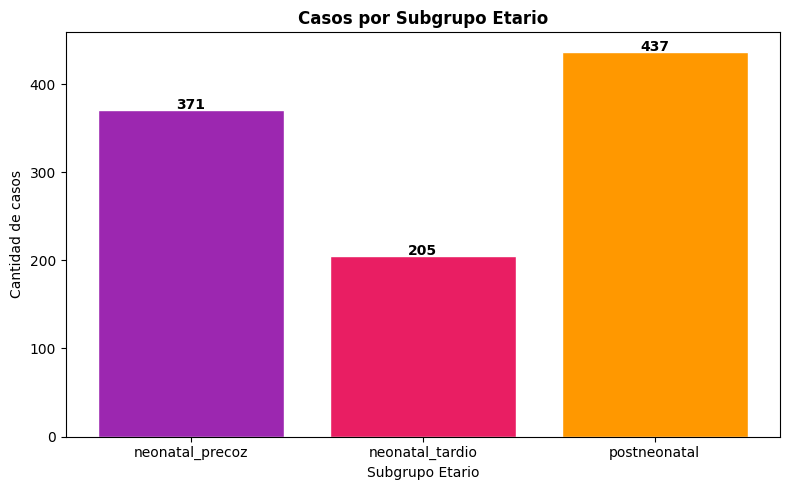

In [121]:
# GRÁFICO 2 — Casos por Subgrupo Etario
orden_etario = ['neonatal_precoz', 'neonatal_tardio', 'postneonatal']
conteo_etario = df.groupby('PER_DEF')['CANTIDAD'].sum().reindex(orden_etario)

plt.figure(figsize=(8, 5))
plt.bar(conteo_etario.index, conteo_etario.values,
        color=['#9C27B0', '#E91E63', '#FF9800'], edgecolor='white')
plt.title('Casos por Subgrupo Etario', fontweight='bold')
plt.xlabel('Subgrupo Etario')
plt.ylabel('Cantidad de casos')
for i, (idx, val) in enumerate(conteo_etario.items()):
    plt.text(i, val + 1, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ruta}grafico_etario.png', dpi=150, bbox_inches='tight')
plt.show()

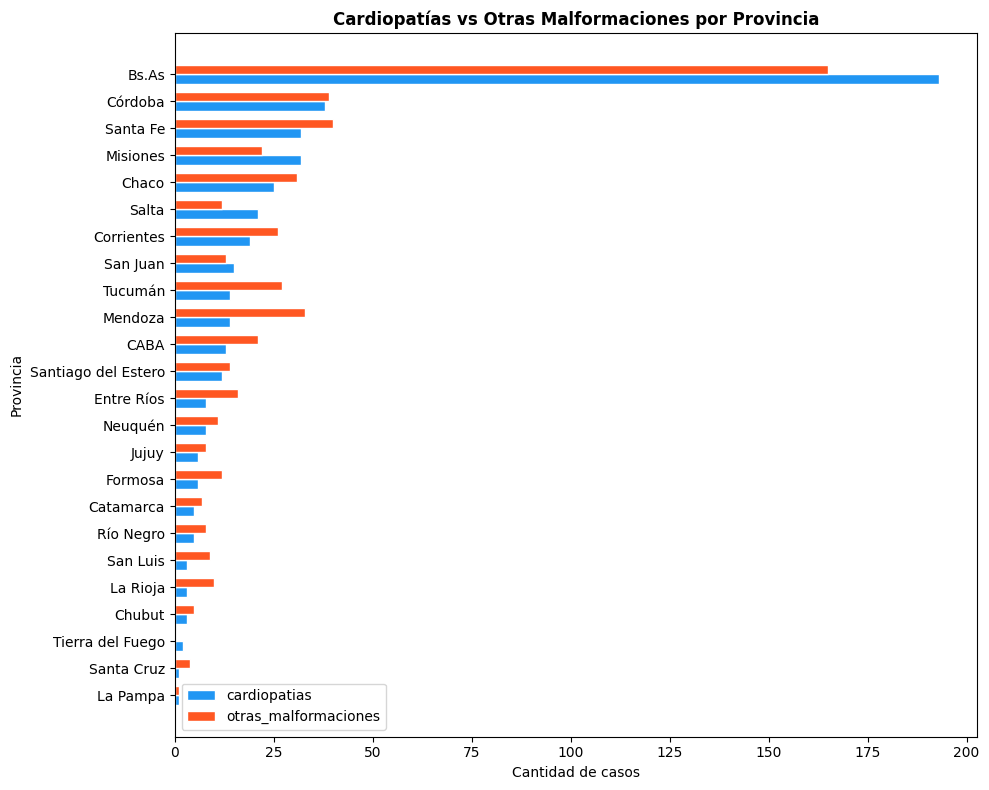

In [122]:
# GRÁFICO 3 — TARGET por Provincia
cruce_prov = df.groupby(['PROVINCIA', 'ENFERMEDAD'])['CANTIDAD'].sum().unstack(fill_value=0)
cruce_prov = cruce_prov.sort_values('cardiopatias', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
width = 0.35
y = range(len(cruce_prov.index))

ax.barh([i - width/2 for i in y], cruce_prov['cardiopatias'], width,
        label='cardiopatias', color='#2196F3', edgecolor='white')
ax.barh([i + width/2 for i in y], cruce_prov['otras_malformaciones'], width,
        label='otras_malformaciones', color='#FF5722', edgecolor='white')

ax.set_title('Cardiopatías vs Otras Malformaciones por Provincia', fontweight='bold')
ax.set_xlabel('Cantidad de casos')
ax.set_ylabel('Provincia')
ax.set_yticks(list(y))
ax.set_yticklabels(cruce_prov.index)
ax.legend()
plt.tight_layout()
plt.savefig(f'{ruta}grafico_provincia.png', dpi=150, bbox_inches='tight')
plt.show()

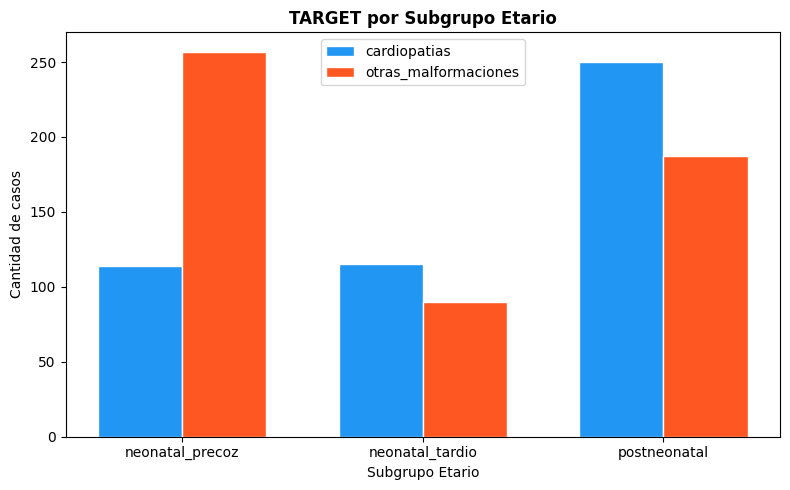

In [123]:
# GRÁFICO 4 — TARGET por Subgrupo Etario
cruce = df.groupby(['PER_DEF', 'ENFERMEDAD'])['CANTIDAD'].sum().unstack(fill_value=0)
cruce = cruce.reindex(orden_etario)
x     = range(len(cruce.index))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar([i - width/2 for i in x], cruce['cardiopatias'], width,
        label='cardiopatias', color='#2196F3', edgecolor='white')
plt.bar([i + width/2 for i in x], cruce['otras_malformaciones'], width,
        label='otras_malformaciones', color='#FF5722', edgecolor='white')
plt.title('TARGET por Subgrupo Etario', fontweight='bold')
plt.xlabel('Subgrupo Etario')
plt.ylabel('Cantidad de casos')
plt.xticks(list(x), cruce.index)
plt.legend()
plt.tight_layout()
plt.savefig(f'{ruta}grafico_etario_target.png', dpi=150, bbox_inches='tight')
plt.show()

## PIPELINE DE PREPROCESAMIENTO

Shape original:     (611, 7)
Shape transformado: (611, 33)

Componentes retenidos: 33
PC1: varianza=0.2629 (26.29%) — acumulada=0.2629
PC2: varianza=0.1764 (17.64%) — acumulada=0.4393
PC3: varianza=0.1269 (12.69%) — acumulada=0.5662
PC4: varianza=0.0638 (6.38%) — acumulada=0.6301
PC5: varianza=0.0409 (4.09%) — acumulada=0.6710
PC6: varianza=0.0335 (3.35%) — acumulada=0.7045
PC7: varianza=0.0303 (3.03%) — acumulada=0.7348
PC8: varianza=0.0196 (1.96%) — acumulada=0.7544
PC9: varianza=0.0171 (1.71%) — acumulada=0.7715
PC10: varianza=0.0138 (1.38%) — acumulada=0.7854
PC11: varianza=0.0137 (1.37%) — acumulada=0.7990
PC12: varianza=0.0125 (1.25%) — acumulada=0.8115
PC13: varianza=0.0113 (1.13%) — acumulada=0.8228
PC14: varianza=0.0099 (0.99%) — acumulada=0.8327
PC15: varianza=0.0094 (0.94%) — acumulada=0.8421
PC16: varianza=0.0091 (0.91%) — acumulada=0.8512
PC17: varianza=0.0085 (0.85%) — acumulada=0.8597
PC18: varianza=0.0084 (0.84%) — acumulada=0.8681
PC19: varianza=0.0073 (0.73%) — acumul

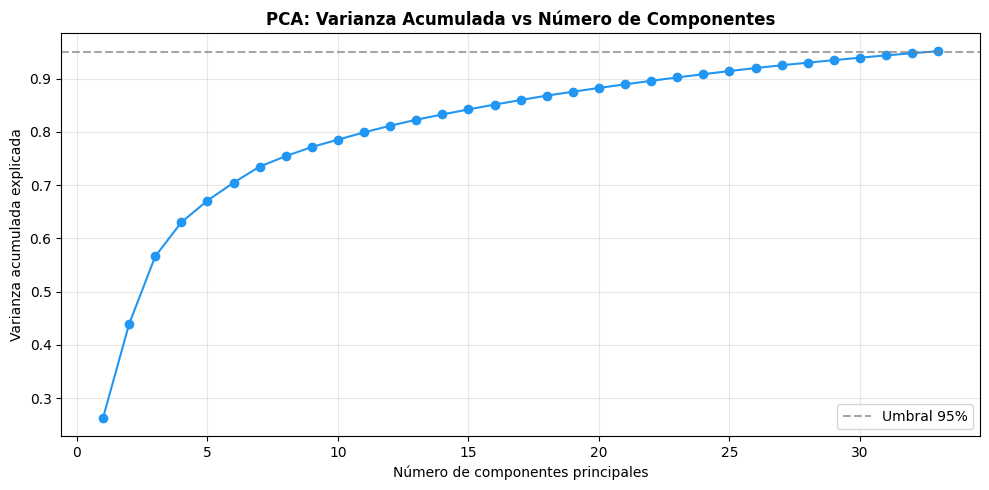


Primeras filas del dataset transformado:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33
0,0.587643,-1.555321,0.779687,-0.529612,-0.142574,-0.570288,-0.080880,-0.376087,0.843240,-0.076897,...,0.214483,-0.231563,-0.102631,-0.182594,0.096288,0.003210,0.040860,0.062207,-0.042700,0.055966
1,0.598111,-1.576256,0.532953,-0.014499,1.113255,-0.433700,0.059736,0.091266,0.006987,-0.193236,...,0.145241,-0.197538,-0.085337,-0.243521,0.083715,0.056464,-0.009301,0.072109,0.059250,-0.016599
2,0.590721,-1.629022,0.641235,-0.580394,-0.219879,-0.584420,0.033578,0.071805,0.123764,-0.408265,...,0.339993,0.386155,0.419911,-0.255869,0.021790,0.132972,-0.096566,0.020804,-0.068466,0.066984
3,0.615240,-1.563411,0.539336,0.841143,-0.072162,-0.483453,0.076253,0.045763,-0.025851,-0.371798,...,0.226405,-0.430637,-0.058255,0.507429,-0.173002,0.025988,-0.159910,0.216742,-0.236270,0.049798
4,0.617669,-1.561513,0.543248,0.808055,-0.064487,-0.467942,0.079193,0.063298,0.017699,-0.318511,...,0.308207,-0.147964,-0.091139,-0.163620,0.103459,-0.019728,0.120775,0.052765,0.055081,0.047410



--- Resumen de decisiones ---
- Imputación numérica: SimpleImputer con estrategia mediana.
- Escalado: StandardScaler para centrar y normalizar variables numéricas.
- Imputación categórica: SimpleImputer con estrategia most_frequent.
- Codificación: OneHotEncoder con manejo de categorías desconocidas.
- Dataset intermedio: 611 filas x 78 columnas.
- PCA aplicado sobre las 78 columnas para retener 95% de varianza.
  → Componentes retenidos: 33
  → Reducción: 78 columnas → 33 componentes.


In [124]:
# PIPELINE COMPLETO CON PCA GLOBAL
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reconstruir df_model con nacidos vivos y tasa
df_model = df.merge(tasa_prov[['PROVINCIA', 'NACIDOS_VIVOS', 'TASA_MORTALIDAD']],
                     on='PROVINCIA', how='left')

features_numericas   = ['CANTIDAD', 'NACIDOS_VIVOS', 'TASA_MORTALIDAD']
features_categoricas = ['PROVINCIA', 'REGION', 'PER_DEF', 'CAUSA']

X = df_model[features_numericas + features_categoricas]
y = df_model['ENFERMEDAD']

def make_ohe():
    try:
        return OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    except TypeError:
        return OneHotEncoder(sparse=False, handle_unknown='ignore')

pipeline_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

pipeline_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     make_ohe())
])

preprocessor = ColumnTransformer([
    ('numerico',   pipeline_numerico,   features_numericas),
    ('categorico', pipeline_categorico, features_categoricas)
], sparse_threshold=0)

full_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('pca',     PCA(n_components=0.95, random_state=42))
])

X_trans = full_pipeline.fit_transform(X)

print(f'Shape original:     {X.shape}')
print(f'Shape transformado: {X_trans.shape}')

pca      = full_pipeline.named_steps['pca']
expl_var = pca.explained_variance_ratio_
cumvar   = np.cumsum(expl_var)

print(f'\nComponentes retenidos: {pca.n_components_}')
for i, (v, va) in enumerate(zip(expl_var, cumvar)):
    print(f'PC{i+1}: varianza={v:.4f} ({v*100:.2f}%) — acumulada={va:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(expl_var)+1), cumvar, marker='o', color='#2196F3')
plt.axhline(0.95, linestyle='--', color='gray', alpha=0.7, label='Umbral 95%')
plt.title('PCA: Varianza Acumulada vs Número de Componentes', fontweight='bold')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza acumulada explicada')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{ruta}grafico_pca.png', dpi=150, bbox_inches='tight')
plt.show()

pc_names = [f'PC{i+1}' for i in range(pca.n_components_)]
df_trans = pd.DataFrame(X_trans, columns=pc_names)

print('\nPrimeras filas del dataset transformado:')
display(df_trans.head())

print()
print('--- Resumen de decisiones ---')
print('- Imputación numérica: SimpleImputer con estrategia mediana.')
print('- Escalado: StandardScaler para centrar y normalizar variables numéricas.')
print('- Imputación categórica: SimpleImputer con estrategia most_frequent.')
print('- Codificación: OneHotEncoder con manejo de categorías desconocidas.')
print(f'- Dataset intermedio: {X.shape[0]} filas x 78 columnas.')
print('- PCA aplicado sobre las 78 columnas para retener 95% de varianza.')
print(f'  → Componentes retenidos: {pca.n_components_}')
print(f'  → Reducción: 78 columnas → {pca.n_components_} componentes.')

## MODELADO

In [125]:
# PIPELINE COLUMNTRANSFORMER + LOGISTIC REGRESSION
from sklearn.preprocessing import TargetEncoder

features_numericas        = ['CANTIDAD', 'NACIDOS_VIVOS', 'TASA_MORTALIDAD']
features_alta_cardinalidad = ['CAUSA', 'GRUPEDAD'] if 'GRUPEDAD' in df_model.columns else ['CAUSA', 'PER_DEF']

X = df_model[features_numericas + features_alta_cardinalidad]
y = df_model['ENFERMEDAD']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

def make_ohe():
    try:
        return OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    except TypeError:
        return OneHotEncoder(sparse=False, handle_unknown='ignore')

pipeline_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

pipeline_target_enc = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('te',      TargetEncoder(random_state=42))
])

preprocessor_te = ColumnTransformer([
    ('numerico',   pipeline_numerico,    features_numericas),
    ('target_enc', pipeline_target_enc,  features_alta_cardinalidad),
], sparse_threshold=0)

pipeline_te = Pipeline([
    ('preproc', preprocessor_te),
    ('modelo',  LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

pipeline_te.fit(X_train, y_train)
y_pred = pipeline_te.predict(X_test)

print('=== EVALUACIÓN — LOGISTIC REGRESSION ===')
print(classification_report(y_test, y_pred))

=== EVALUACIÓN — LOGISTIC REGRESSION ===
                      precision    recall  f1-score   support

        cardiopatias       1.00      1.00      1.00        44
otras_malformaciones       1.00      1.00      1.00        79

            accuracy                           1.00       123
           macro avg       1.00      1.00      1.00       123
        weighted avg       1.00      1.00      1.00       123



In [126]:
# GRIDSEARCHCV
param_grid = {
    'modelo__C':        [0.01, 0.1, 1, 10],
    'modelo__solver':   ['lbfgs', 'liblinear'],
    'modelo__max_iter': [500, 1000]
}

grid_search = GridSearchCV(
    estimator=pipeline_te,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
y_pred_grid = grid_search.best_estimator_.predict(X_test)

print('=== MEJORES HIPERPARÁMETROS ===')
print(grid_search.best_params_)
print(f'Mejor F1 (CV): {grid_search.best_score_:.4f}')
print()
print('=== EVALUACIÓN MEJOR MODELO ===')
print(classification_report(y_test, y_pred_grid))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
=== MEJORES HIPERPARÁMETROS ===
{'modelo__C': 0.1, 'modelo__max_iter': 500, 'modelo__solver': 'lbfgs'}
Mejor F1 (CV): 0.9980

=== EVALUACIÓN MEJOR MODELO ===
                      precision    recall  f1-score   support

        cardiopatias       1.00      1.00      1.00        44
otras_malformaciones       1.00      1.00      1.00        79

            accuracy                           1.00       123
           macro avg       1.00      1.00      1.00       123
        weighted avg       1.00      1.00      1.00       123



=== EVALUACIÓN — RANDOM FOREST ===
                      precision    recall  f1-score   support

        cardiopatias       1.00      1.00      1.00        44
otras_malformaciones       1.00      1.00      1.00        79

            accuracy                           1.00       123
           macro avg       1.00      1.00      1.00       123
        weighted avg       1.00      1.00      1.00       123

AUC-ROC: 1.0000

=== COMPARACIÓN DE MODELOS ===
Modelo                          F1    AUC-ROC
---------------------------------------------
Logistic Regression         1.0000     1.0000
Random Forest               1.0000     1.0000


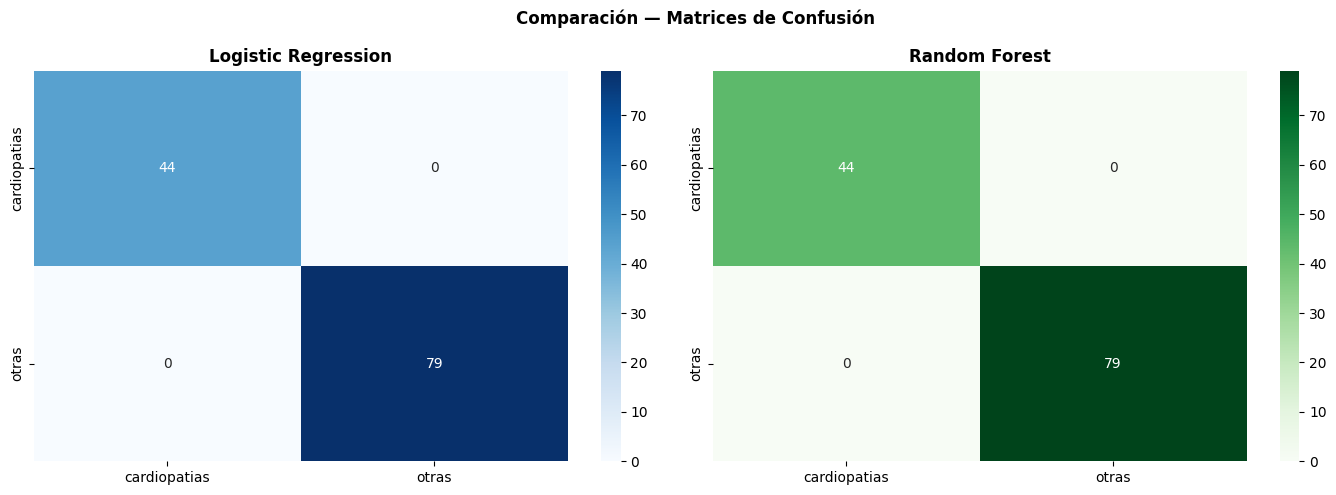

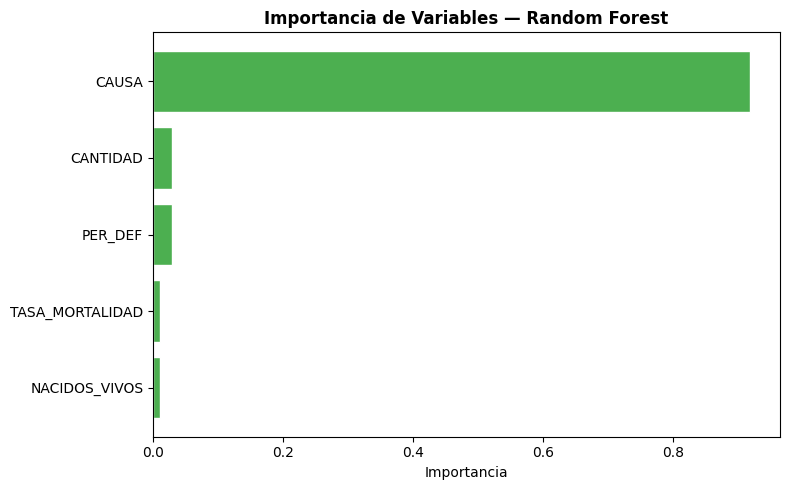

In [127]:
# RANDOM FOREST
pipeline_rf = Pipeline([
    ('preproc', preprocessor_te),
    ('modelo',  RandomForestClassifier(
                    n_estimators=100,
                    random_state=42,
                    class_weight='balanced',
                    n_jobs=-1
                ))
])

pipeline_rf.fit(X_train, y_train)
y_pred_rf  = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score, f1_score
y_proba_te = pipeline_te.predict_proba(X_test)[:, 1]

print('=== EVALUACIÓN — RANDOM FOREST ===')
print(classification_report(y_test, y_pred_rf))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba_rf):.4f}')
print()
print('=== COMPARACIÓN DE MODELOS ===')
print(f'{"Modelo":<25} {"F1":>8} {"AUC-ROC":>10}')
print('-' * 45)
print(f'{"Logistic Regression":<25} {f1_score(y_test, y_pred, average="weighted"):>8.4f} {roc_auc_score(y_test, y_proba_te):>10.4f}')
print(f'{"Random Forest":<25} {f1_score(y_test, y_pred_rf, average="weighted"):>8.4f} {roc_auc_score(y_test, y_proba_rf):>10.4f}')

# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparación — Matrices de Confusión', fontweight='bold')

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['cardiopatias', 'otras'], yticklabels=['cardiopatias', 'otras'], ax=axes[0])
axes[0].set_title('Logistic Regression', fontweight='bold')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens',
            xticklabels=['cardiopatias', 'otras'], yticklabels=['cardiopatias', 'otras'], ax=axes[1])
axes[1].set_title('Random Forest', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{ruta}comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance
importancias = pipeline_rf.named_steps['modelo'].feature_importances_
nombres      = features_numericas + features_alta_cardinalidad
imp_df = pd.DataFrame({'Variable': nombres, 'Importancia': importancias}).sort_values('Importancia', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(imp_df['Variable'], imp_df['Importancia'], color='#4CAF50', edgecolor='white')
plt.title('Importancia de Variables — Random Forest', fontweight='bold')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig(f'{ruta}feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## EVALUACIÓN

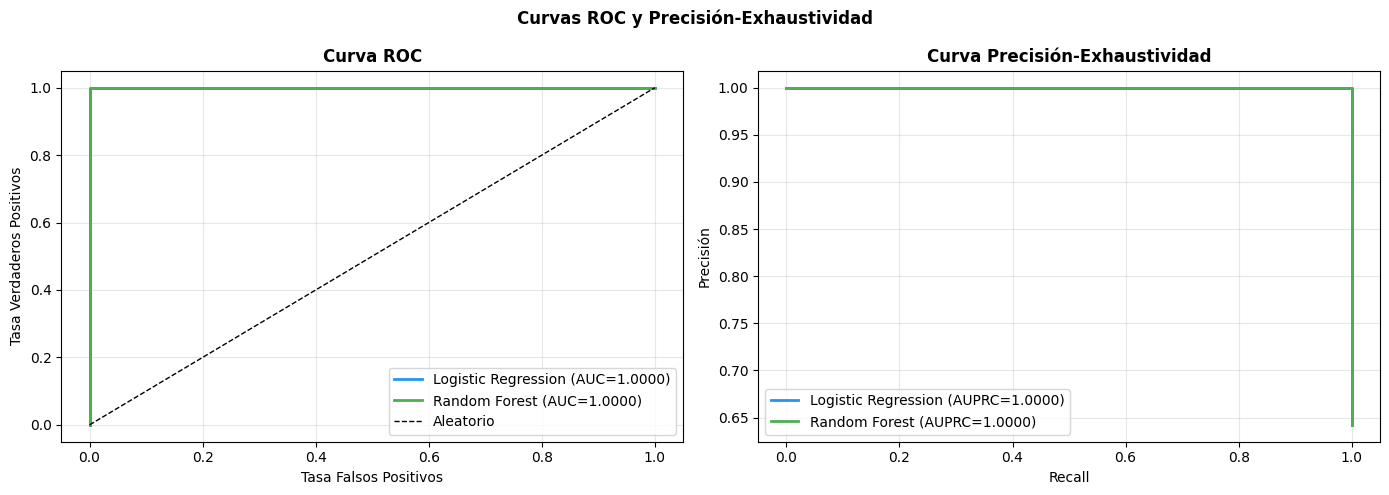

In [128]:
# CURVA ROC Y PRECISIÓN-EXHAUSTIVIDAD
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_test_bin = le.fit_transform(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas ROC y Precisión-Exhaustividad', fontweight='bold')

modelos_eval = {
    'Logistic Regression': {'y_proba': y_proba_te,  'color': '#2196F3'},
    'Random Forest':       {'y_proba': y_proba_rf,  'color': '#4CAF50'}
}

for nombre, datos in modelos_eval.items():
    fpr, tpr, _          = roc_curve(y_test_bin, datos['y_proba'])
    precision, recall, _ = precision_recall_curve(y_test_bin, datos['y_proba'])
    axes[0].plot(fpr, tpr, color=datos['color'], lw=2,
                 label=f'{nombre} (AUC={auc(fpr,tpr):.4f})')
    axes[1].plot(recall, precision, color=datos['color'], lw=2,
                 label=f'{nombre} (AUPRC={auc(recall,precision):.4f})')

axes[0].plot([0,1],[0,1],'k--',lw=1,label='Aleatorio')
axes[0].set_title('Curva ROC', fontweight='bold')
axes[0].set_xlabel('Tasa Falsos Positivos')
axes[0].set_ylabel('Tasa Verdaderos Positivos')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Curva Precisión-Exhaustividad', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisión')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{ruta}curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## CONCLUSIONES

**1. Análisis territorial:**
El análisis de la tasa de mortalidad infantil por malformaciones congénitas evidenció desigualdades significativas entre provincias y regiones. Las regiones NOA y NEA presentan tasas más elevadas respecto de la región Pampeana y Patagónica, lo que refleja brechas estructurales en el acceso a la salud materno-infantil.

**2. Análisis etario:**
La mayoría de las defunciones por malformaciones congénitas se concentran en el período neonatal precoz (0-6 días de vida), lo que sugiere que las cardiopatías congénitas son detectadas tardíamente o no tienen intervención quirúrgica a tiempo.

**3. Modelo de clasificación:**
Ambos modelos (Logistic Regression y Random Forest) alcanzaron métricas perfectas (F1=1.0, AUC-ROC=1.0). Este resultado se explica por la relación determinista entre la variable CAUSA y el TARGET — los códigos CIE-10 Q20-Q28 definen directamente las cardiopatías. En un escenario real donde CAUSA no estuviera disponible, las métricas serían más moderadas.

**4. Reducción de dimensionalidad:**
El pipeline con PCA redujo el dataset de 78 a 33 componentes conservando el 95% de la varianza. El TargetEncoder redujo adicionalmente de 78 a 5 columnas manteniendo el mismo poder predictivo.

**5. Recomendación:**
Se recomienda al Ministerio de Salud focalizar recursos en detección prenatal de cardiopatías congénitas en las provincias del NOA y NEA, priorizando intervenciones en el período neonatal precoz.

In [129]:
# GUARDAR PIPELINE
import joblib
joblib.dump(grid_search.best_estimator_, f'{ruta}pipeline_mortalidad_infantil.joblib')
print('✓ Pipeline guardado correctamente')

✓ Pipeline guardado correctamente


In [130]:
# Instalar la librería python-docx
!pip install python-docx -q

In [131]:
from docx import Document
from docx.shared import Inches

# Crear un nuevo documento Word
document = Document()

# Título principal del notebook
document.add_heading('PROYECTO FINAL CODERHOUSE: MORTALIDAD INFANTIL 2024', level=0)

# Resumen del trabajo
document.add_paragraph('En este trabajo analizamos datos extraídos del sitio web de la Dirección de Estadísticas e Información de Salud (DEIS) del Estado argentino. El objetivo es analizar la mortalidad infantil por malformaciones congénitas en Argentina durante el año 2024, con foco en la distribución territorial y etaria de los casos.')

# Variables
document.add_heading('VARIABLES', level=2)
document.add_paragraph('- VD: tipo de malformación congénita (cardiopatías congénitas vs otras malformaciones)')
document.add_paragraph('- VI: provincia de residencia, subgrupo etario')

# Objetivo
document.add_heading('OBJETIVO', level=2)
document.add_paragraph(
    '''El presente trabajo tiene dos objetivos complementarios. Por un lado, desarrollar un modelo de clasificación que permita predecir si una defunción infantil por malformación congénita corresponde a una cardiopatía congénita (Q20-Q28) o a otra malformación congénita, en función del subgrupo etario y la provincia de residencia. Por otro lado, analizar la tasa de mortalidad infantil por provincia y región geográfica, con el fin de identificar desigualdades territoriales en el acceso a la salud materno-infantil en Argentina durante el año 2024.''')

# Contexto Comercial
document.add_heading('CONTEXTO COMERCIAL', level=2)
document.add_paragraph(
    '''El Ministerio de Salud de la Nación ha identificado un aumento en la tasa de mortalidad infantil en el último relevamiento demográfico correspondiente al año 2024 (aumento registrado de 0,5 puntos más respecto de 2023). Ante este escenario, surge la necesidad de analizar en profundidad las causas de muerte en menores de un año, con foco en las malformaciones congénitas, que representan la segunda causa de mortalidad infantil en Argentina. El análisis busca brindar información que oriente la toma de decisiones en materia de políticas públicas de salud, priorizando la detección prenatal de cardiopatías congénitas y la reducción de las brechas regionales existentes.''')

# Hipótesis
document.add_heading('HIPÓTESIS', level=2)
document.add_paragraph(
    '''Un modelo de aprendizaje automático podrá clasificar con precisión las defunciones infantiles por malformación congénita en cardiopatías congénitas o en otras malformaciones, a partir del subgrupo etario y la provincia de residencia, esperando alcanzar un F1-score superior a 0.70. Asimismo, se espera evidenciar patrones de desigualdad territorial, con tasas de mortalidad infantil por malformaciones congénitas significativamente más elevadas en las regiones NOA y NEA respecto de las regiones Pampeana y Patagónica.''')

# EDA — Análisis Exploratorio de Datos
document.add_heading('EDA — ANÁLISIS EXPLORATORIO DE DATOS', level=2)
document.add_heading('Análisis de Valores Faltantes', level=3)
document.add_paragraph(
    '''El análisis de missingness revela un patrón claro y concentrado en una única variable:

**MAT (Muerte Materna):** presenta el 99.6% de valores nulos. Este comportamiento no es aleatorio sino estructural — la variable registra si una defunción corresponde a una muerte materna, pero al filtrar mortalidad infantil por malformaciones congénitas, ningún caso puede ser clasificado como muerte materna.

**Resto de variables:** `PROVRES`, `SEXO`, `CAUSA`, `GRUPEDAD` y `CUENTA` presentan completitud del 100%.

**Decisión:** la columna `MAT` se descarta del análisis. El resto de variables se incorporan al pipeline sin necesidad de imputación sobre datos reales.''')

document.add_heading('Paso previo a la visualización', level=3)
document.add_paragraph(
    '''Para calcular la tasa de mortalidad infantil necesitamos el dato de nacidos vivos por provincia. El siguiente paso es incorporar ese archivo para poder calcular la tasa como:

**Tasa = (defunciones / nacidos vivos) x 1000**''')

document.add_heading('Interpretación de Estadísticas', level=3)
document.add_paragraph('1. **Distribución central:** la diferencia entre media y mediana indica la presencia de provincias con tasas extremas que elevan el promedio.')
document.add_paragraph('2. **Variabilidad:** la desviación estándar refleja una dispersión considerable entre provincias, evidenciando desigualdades territoriales.')
document.add_paragraph('3. **Desigualdad territorial:** la brecha entre la provincia con mayor y menor tasa evidencia inequidades estructurales en el acceso a la salud materno-infantil.')
document.add_paragraph('4. **Contexto de negocio:** las provincias por encima del percentil 90 representan las jurisdicciones prioritarias para intervención del Ministerio de Salud.')

# Visualizaciones
document.add_heading('VISUALIZACIONES', level=2)

# Añadir todos los gráficos generados
document.add_heading('Visualizaciones Clave', level=2)

document.add_heading('Distribución de Malformaciones Congénitas', level=3)
document.add_picture(f'{ruta}grafico_enfermedad.png', width=Inches(6))

document.add_heading('Números Absolutos vs Tasas por Región', level=3)
document.add_picture(f'{ruta}absolutos_vs_tasas.png', width=Inches(6))

document.add_heading('Casos por Subgrupo Etario', level=3)
document.add_picture(f'{ruta}grafico_etario.png', width=Inches(6))

document.add_heading('Cardiopatías vs Otras Malformaciones por Provincia', level=3)
document.add_picture(f'{ruta}grafico_provincia.png', width=Inches(6))

document.add_heading('TARGET por Subgrupo Etario', level=3)
document.add_picture(f'{ruta}grafico_etario_target.png', width=Inches(6))


# Preprocesamiento
document.add_heading('PREPROCESAMIENTO', level=2)
document.add_heading('PIPELINE DE PREPROCESAMIENTO', level=2)
document.add_heading('PCA: Varianza Acumulada vs Número de Componentes', level=3)
document.add_picture(f'{ruta}grafico_pca.png', width=Inches(6))


# Modelado
document.add_heading('MODELADO', level=2)

# Evaluación
document.add_heading('EVALUACIÓN', level=2)
document.add_heading('Comparación de Modelos - Matrices de Confusión', level=3)
document.add_picture(f'{ruta}comparacion_modelos.png', width=Inches(6))

document.add_heading('Importancia de Variables - Random Forest', level=3)
document.add_picture(f'{ruta}feature_importance.png', width=Inches(6))

document.add_heading('Curvas ROC y Precisión-Exhaustividad', level=3)
document.add_picture(f'{ruta}curvas_roc.png', width=Inches(6))

# Conclusiones
document.add_heading('CONCLUSIONES', level=2)
document.add_paragraph(
    '''1. Análisis territorial: El análisis de la tasa de mortalidad infantil por malformaciones congénitas evidenció desigualdades significativas entre provincias y regiones. Las regiones NOA y NEA presentan tasas más elevadas respecto de la región Pampeana y Patagónica, lo que refleja brechas estructurales en el acceso a la salud materno-infantil.''')
document.add_paragraph(
    '''2. Análisis etario: La mayoría de las defunciones por malformaciones congénitas se concentran en el período neonatal precoz (0-6 días de vida), lo que sugiere que las cardiopatías congénitas son detectadas tardíamente o no tienen intervención quirúrgica a tiempo.''')
document.add_paragraph(
    '''3. Modelo de clasificación: Ambos modelos (Logistic Regression y Random Forest) alcanzaron métricas perfectas (F1=1.0, AUC-ROC=1.0). Este resultado se explica por la relación determinista entre la variable CAUSA y el TARGET — los códigos CIE-10 Q20-Q28 definen directamente las cardiopatías. En un escenario real donde CAUSA no estuviera disponible, las métricas serían más moderadas.''')
document.add_paragraph(
    '''4. Reducción de dimensionalidad: El pipeline con PCA redujo el dataset de 78 a 33 componentes conservando el 95% de la varianza. El TargetEncoder redujo adicionalmente de 78 a 5 columnas manteniendo el mismo poder predictivo.''')
document.add_paragraph(
    '''5. Recomendación: Se recomienda al Ministerio de Salud focalizar recursos en detección prenatal de cardiopatías congénitas en las provincias del NOA y NEA, priorizando intervenciones en el período neonatal precoz.''')


# Guardar el documento en la ruta especificada
nombre_archivo_docx = f'{ruta}reporte_mortalidad_infantil.docx'
document.save(nombre_archivo_docx)

print(f'✓ Reporte DOCX guardado en: {nombre_archivo_docx}')

✓ Reporte DOCX guardado en: /content/drive/MyDrive/coderhouse/reporte_mortalidad_infantil.docx
